# Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

# Load data

In [2]:
LOAD_PATH = Path("../data/data.parquet")
data = pd.read_parquet(LOAD_PATH)
print("\nShape of data:", data.shape)
data.head()


Shape of data: (9089, 32)


,index,value,coordinates,period.label,period.interval,period.datetime_from.utc,period.datetime_from.local,period.datetime_to.utc,period.datetime_to.local,parameter.id,...,coverage.expected_count,coverage.expected_interval,coverage.observed_count,coverage.observed_interval,coverage.percent_complete,coverage.percent_coverage,coverage.datetime_from.utc,coverage.datetime_from.local,coverage.datetime_to.utc,coverage.datetime_to.local
0,0,64.5,None,1hour,01:00:00,2024-12-31T23:00:00Z,2025-01-01T00:00:00+01:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2024-12-31T23:00:00Z,2025-01-01T00:00:00+01:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00
1,1,476.0,None,1hour,01:00:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00
2,2,475.0,None,1hour,01:00:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00
3,3,361.0,None,1hour,01:00:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00
4,4,310.0,None,1hour,01:00:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2025-01-01T04:00:00Z,2025-01-01T05:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2025-01-01T04:00:00Z,2025-01-01T05:00:00+01:00


In [3]:
df = data.pivot(
    columns="parameter.name",
    index="period.datetime_from.local",
    values="value"
).reset_index().copy()

In [4]:
df = df.rename(columns={
    "period.datetime_from.local": "timestamp",
})

In [6]:
df = df.loc[:, ["timestamp", "pm25"]]

In [12]:
pd.to_datetime(df['timestamp'][0])

Timestamp('2025-01-01 00:00:00+0100', tz='UTC+01:00')

# Feature engineering

## Date features

In [7]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].apply(lambda day: is_weekend(day))
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2* np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2* np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

## Rolling & lag

In [15]:
target = 'pm25'
lag_periods = [3, 6, 9, 12]
rolling_window = [12]

In [16]:
for window in rolling_window:
    df[f'rolling_{target}_{str(window)}'] = df[target].rolling(window=window).mean()

for period in lag_periods:
    df[f'lag_{target}_{str(period)}'] = df[target].shift(periods=period)

## Shifted target

In [33]:
df['target'] = df[target].shift(-12)

In [34]:
df = df.dropna()

# Create data splits

In [35]:
train_idx = int(np.ceil(len(df) * .9))

In [36]:
train_df = df.loc[:train_idx, :]
test_df = df.loc[train_idx:, :]

In [37]:
X_train = train_df.drop(['timestamp', 'target'], axis=1)
y_train = train_df.loc[:, 'target']

X_test = test_df.drop(['timestamp', 'target'], axis=1)
y_test = test_df.loc[:, 'target']

train_timestamp = train_df.loc[:, 'timestamp']
test_timestamp = test_df.loc[:, 'timestamp']

# Train model

## Baseline (Ridge)

In [38]:
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [39]:
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)

print("MAE", mae)
print("r2", r2)

MAE 7.86264848008179
r2 0.32028304792078643


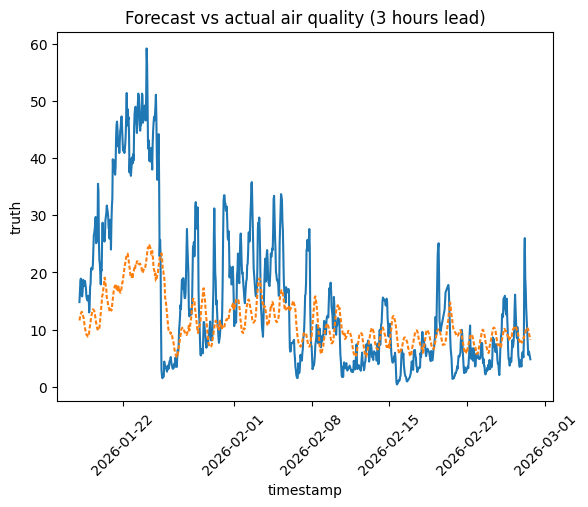

In [40]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_hat
    }
)

sns.lineplot(y_hat_df, x="timestamp", y="truth")
sns.lineplot(y_hat_df, x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

In [41]:
y_hat_df.head()

,timestamp,truth,pred
8146,2026-01-18 03:00:00+00:00,14.8,11.575782
8147,2026-01-18 04:00:00+00:00,16.4,12.035778
8148,2026-01-18 05:00:00+00:00,18.3,12.617003
8149,2026-01-18 06:00:00+00:00,18.9,12.748978
8150,2026-01-18 07:00:00+00:00,16.6,12.991098


In [42]:
pd.DataFrame(data={
    "coef": clf.coef_,
    "feature": clf.feature_names_in_
}) \
    .sort_values('coef', ascending=False) \
    .reset_index() \
    .drop('index', axis=1)

,coef,feature
0,1.737366,month_sin
1,1.397242,hour_sin
2,1.045641,month_cos
3,0.196886,rolling_pm25_12
4,0.112927,pm25
5,0.105959,day_cos
6,0.041397,lag_pm25_3
7,0.020506,lag_pm25_6
8,0.013921,hour_of_day
9,0.006709,month


In [43]:
df.groupby('month').agg({
    'target': 'mean'
})

parameter.name,target
month,
1,14.729089
2,15.198522
3,12.802926
4,9.887747
5,9.748454
6,11.629982
7,8.582444
8,10.981975
9,7.797054


# Final remarks
At the end of this experiment, we observe the following:
- Removing lag and rolling features makes model **useless** (worth than guessing)
- As such, current features (temperature, humidity and temporal features) **do not** have significant explanatory power.
- Further feature engineering is required. Likely candidates:
    - Wind
    - Pressure

# Prophet

In [44]:
from prophet import Prophet

/home/luc/Documents/Projects/air_quality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [45]:
prophet_df = df.loc[:, ["timestamp", "pm25"]]
prophet_df = prophet_df.rename(columns={"timestamp":"ds", "pm25":"y"})

In [46]:
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

In [47]:
m = Prophet()
m.fit(prophet_df)

22:38:56 - cmdstanpy - INFO - Chain [1] start processing
22:38:58 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
# Python
future = m.make_future_dataframe(periods=48)
future.tail()

,ds
9094,2026-04-12 16:00:00
9095,2026-04-13 16:00:00
9096,2026-04-14 16:00:00
9097,2026-04-15 16:00:00
9098,2026-04-16 16:00:00


In [49]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
9094,2026-04-12 16:00:00,12.294362,-8.136476,31.761764
9095,2026-04-13 16:00:00,12.083352,-9.210508,32.798067
9096,2026-04-14 16:00:00,12.739445,-10.336788,33.564944
9097,2026-04-15 16:00:00,14.055510,-8.391311,36.030068
9098,2026-04-16 16:00:00,13.371794,-9.264444,34.608925


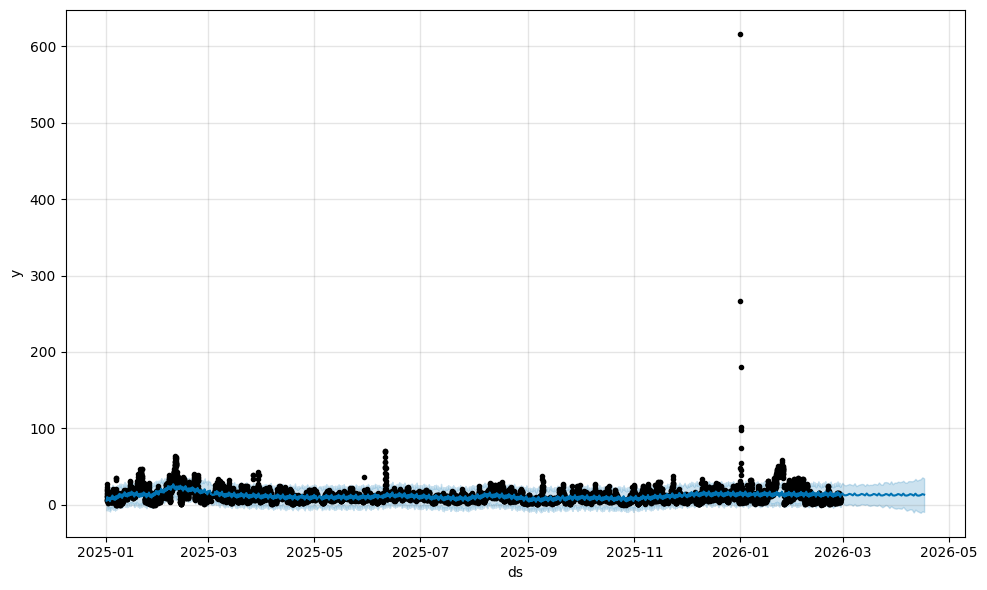

In [50]:
fig1 = m.plot(forecast)

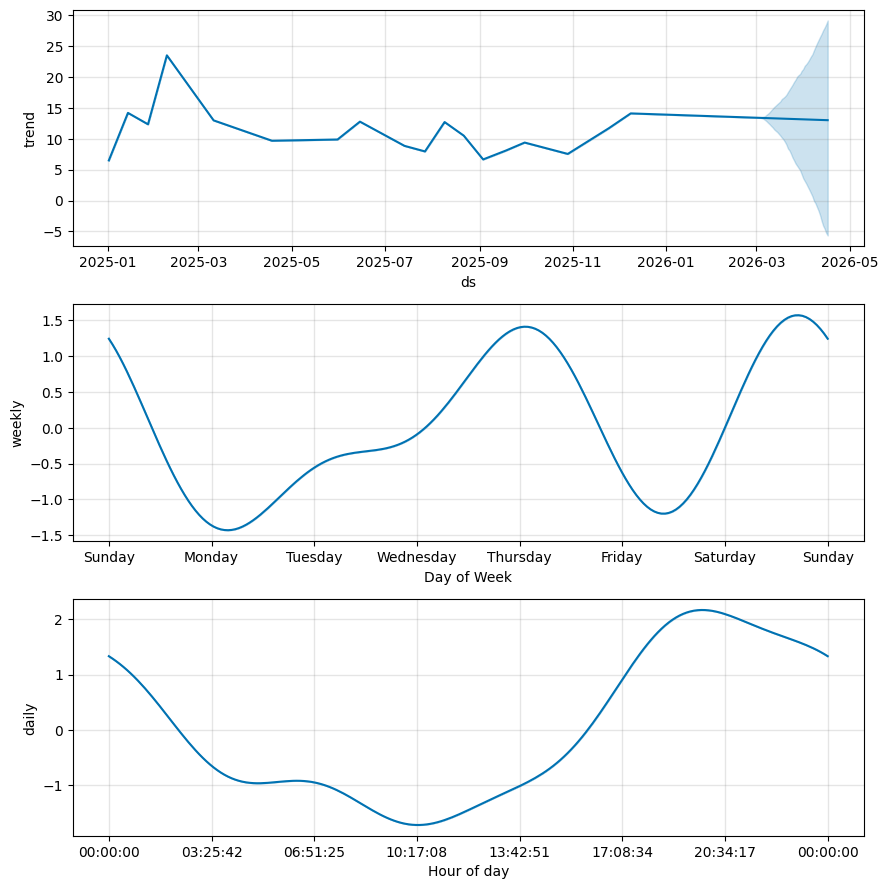

In [51]:
fig2 = m.plot_components(forecast)

In [144]:
df.describe()

parameter.name,pm25,relativehumidity,temperature,year,month,day_of_week,hour_of_day,is_weekend,hour_sin,hour_cos,month_sin,month_cos,day_sin,day_cos,rolling_pm25_12,lag_pm25_3,lag_pm25_6,lag_pm25_9,lag_pm25_12,target
count,1768.000000,1768.000000,1768.000000,1768.0,1768.000000,1768.000000,1768.000000,1768.000000,1.768000e+03,1.768000e+03,1768.000000,1.768000e+03,1768.000000,1768.000000,1768.000000,1768.000000,1768.000000,1768.000000,1768.000000,1768.000000
mean,24.016567,49.399548,10.742649,2026.0,1.909502,2.959276,11.481900,0.138009,2.977264e-03,2.284535e-03,0.771476,4.976606e-01,0.026792,-0.010640,23.983570,24.004406,23.964638,23.959661,23.976855,23.937947
std,19.825053,8.115365,4.693568,0.0,0.782346,1.973949,6.932834,0.345007,7.071273e-01,7.074764e-01,0.208385,3.373776e-01,0.706903,0.707123,18.692551,19.824220,19.823777,19.822739,19.830337,19.781523
min,0.000000,21.000000,-1.220000,2026.0,1.000000,0.000000,0.000000,0.000000,-1.000000e+00,-1.000000e+00,0.500000,6.123234e-17,-0.974928,-0.900969,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.672500,45.775000,7.877500,2026.0,1.000000,1.000000,5.000000,0.000000,-7.071068e-01,-7.071068e-01,0.500000,6.123234e-17,-0.781831,-0.900969,5.830104,3.672500,3.672500,3.672500,3.672500,3.672500
50%,24.050000,51.400000,10.300000,2026.0,2.000000,3.000000,11.000000,0.000000,1.224647e-16,6.123234e-17,0.866025,5.000000e-01,0.000000,-0.222521,23.556667,23.900000,23.650000,23.600000,23.600000,23.850000
75%,40.825000,55.000000,13.000000,2026.0,3.000000,5.000000,17.250000,0.000000,7.071068e-01,7.071068e-01,1.000000,8.660254e-01,0.781831,0.623490,39.902083,40.825000,40.825000,40.825000,40.825000,40.700000
max,67.600000,64.900000,28.400000,2026.0,3.000000,6.000000,23.000000,1.000000,1.000000e+00,1.000000e+00,1.000000,8.660254e-01,0.974928,1.000000,65.183333,67.600000,67.600000,67.600000,67.600000,67.600000
